# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')

In [3]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [4]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


In [ ]:
В наборі 10886 рядків та 19 колонок. Дані представлені з погодинною деталізацією, тобто в одному рядку даних 
міститься інформація за кожну годину.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


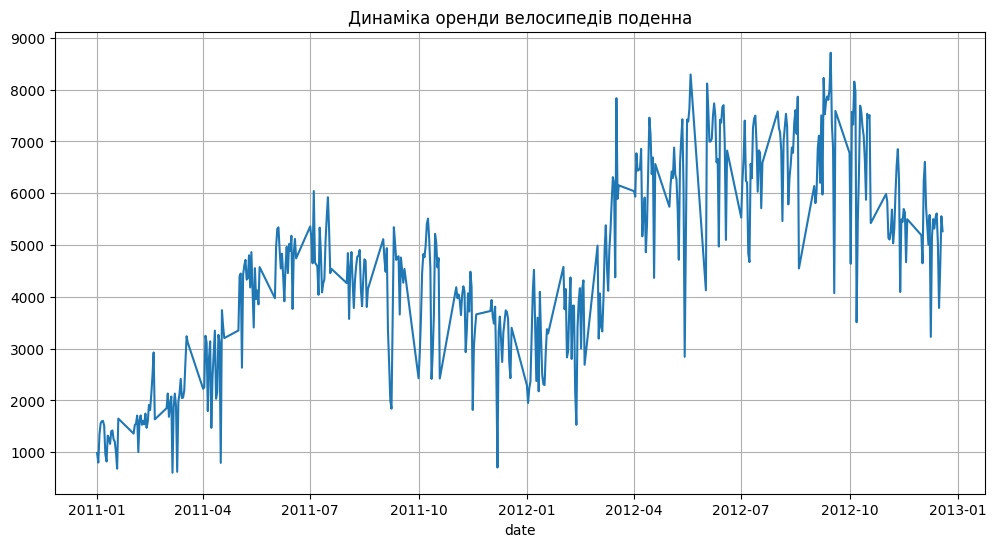

In [7]:
count_of_day = df.groupby('date')['count'].agg(sum)
count_of_day.plot(
    figsize=(12, 6), title='Динаміка оренди велосипедів поденна',grid=True
    )
plt.show()

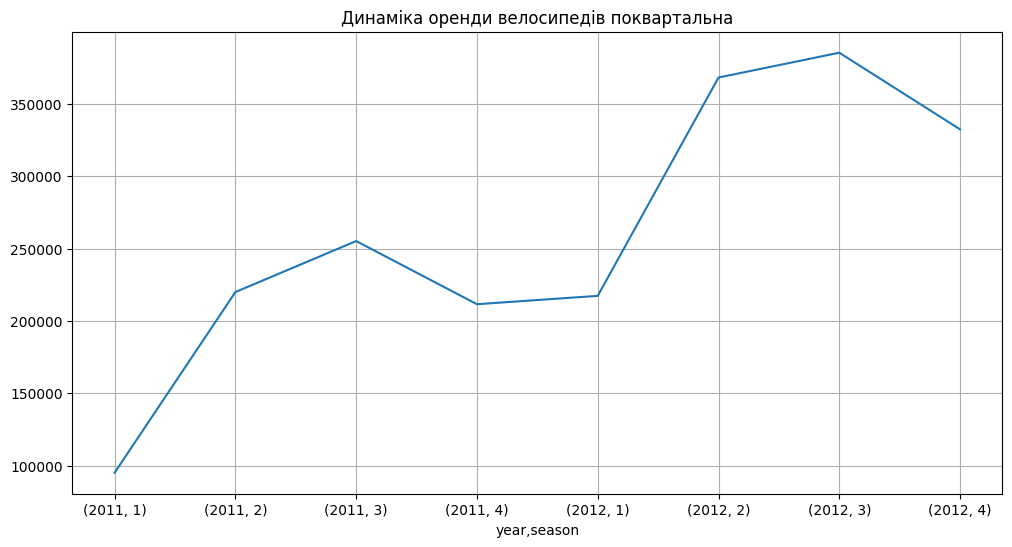

In [8]:
count_of_season = df.groupby(['year','season'])['count'].agg(sum)
count_of_season.plot(
    figsize=(12, 6), title='Динаміка оренди велосипедів поквартальна',grid=True
    )
plt.show()

In [ ]:
Розглянувши поденний та поквартальний графіки динаміки оренди велосипедів можна зробити висновки: 
Заломи на поденному графіку виникають за рахунок наявності днів з високим та низьким попитом на оренду. 
Різкий високий попит може бути викликаний вихідним/святковим днем, чудовою погодою або була проведена маркетингова
активність щось на кшталт бери в оренду два велосипеди, а третій за пів ціни.
Низький попит пов'язаний з поганими погодними умовами або сімейними святами (Різдво, Пасха)
Заломи на поденному графіку пропоную прибрати змінивши деталізацію на поквартальну.
З поквартального графіку бачимо сезонну закономірність оренди, тобто в прохолодні осінні, зимні періоди попит 
на оренду спадає і навпаки росте навесні та влітку.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

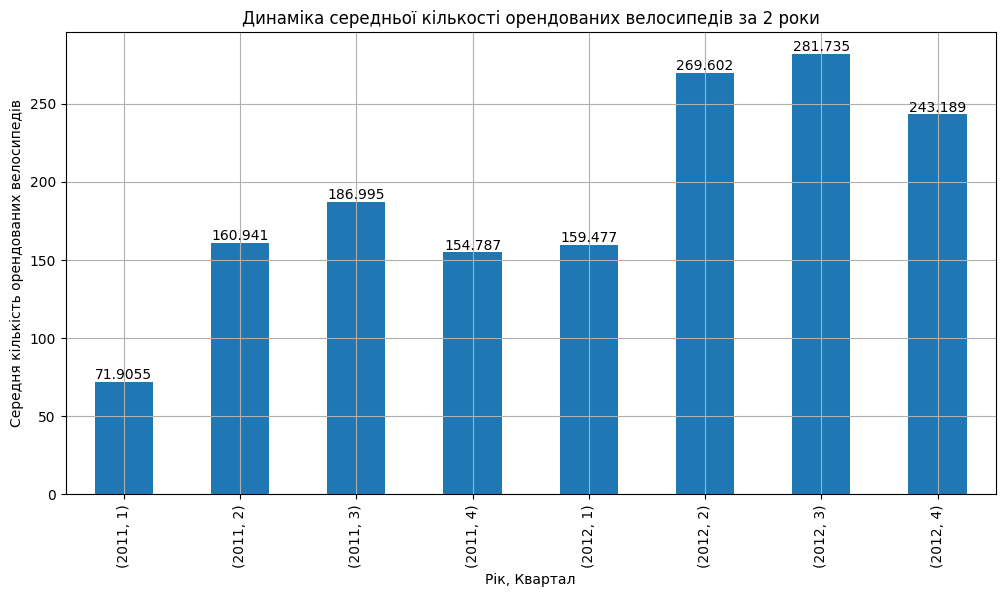

In [9]:
mean_count_of_season = df.groupby(['year','season'])['count'].mean()
ax= mean_count_of_season.plot.bar(
    figsize=(12, 6), 
    title='Динаміка середньої кількості орендованих велосипедів за 2 роки',
    xlabel='Рік, Квартал',
    ylabel='Середня кількість орендованих велосипедів',
    grid=True
)
for container in ax.containers:
    ax.bar_label(container)
plt.show()


In [ ]:
Розглядаючи 2011 та 2012 роки можна сказати, що найбільша середня кількість оренди велосипедів 
в 3 кварталі. Це пов'язано з сприятливими погодними умовами та можливо з періодом відпусток.
Середня кількість оренди в 3 кварталі 2012 року (281 велосипед) приблизно в 4 рази більше середньої кількості
орендованих велосипедів в 1 кварталі 2011 року (71 велосипед).

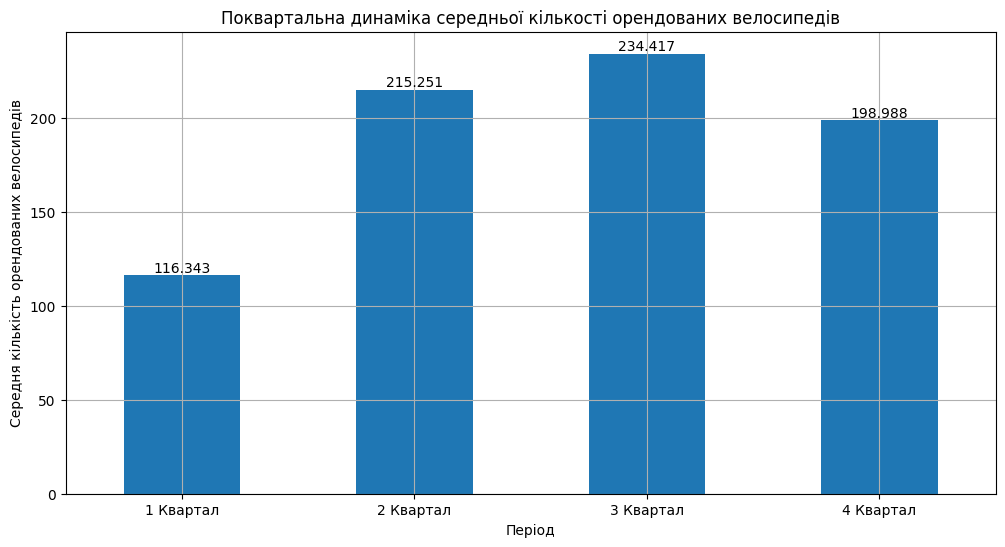

In [10]:
mean_count_of_season1 = df.groupby(['season'])['count'].mean()
ax1= mean_count_of_season1.plot.bar(
    figsize=(12, 6), 
    title='Поквартальна динаміка середньої кількості орендованих велосипедів',
    xlabel='Період',
    ylabel='Середня кількість орендованих велосипедів',
    grid=True
)
for container in ax1.containers:
    ax1.bar_label(container)
ax1.set_xticklabels(['1 Квартал', '2 Квартал', '3 Квартал', '4 Квартал'])
plt.xticks(rotation=0)
plt.show()

In [ ]:
Розглядаючи графік поквартальної оренди велосипедів, бачимо що в 3 кварталі оренда в 2 рази більша ніж в 
1 кварталі. Це пов'язано зі сприятливими погодними умовами для використання велосипедів. 

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


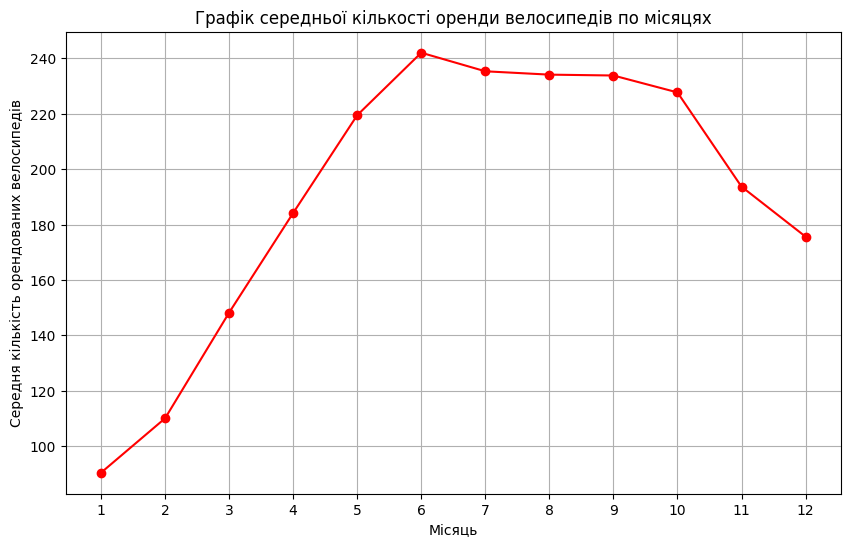

In [11]:
monthly_rents = df.groupby(['month'])['count'].mean()
monthly_rents.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
    title='Графік середньої кількості оренди велосипедів по місяцях',
    xlabel='Місяць',
    ylabel='Середня кількість орендованих велосипедів',
    colormap='autumn',
    xticks = [1,2,3,4,5,6,7,8,9,10,11,12],
    grid=True
)
plt.show()

In [ ]:
Пік оренди припадає на літні місяці, а спад - на холодну пору року, тобто зима, осінь.
Закономірність збігається з попереднім завданням, максимум оренди був в 3 кварталі.
Клімат це першочерговий чинник, який впливає на оренду велосипедів. В дощову, сніжну, вітряну погоду попит на 
велосипеди спадає.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

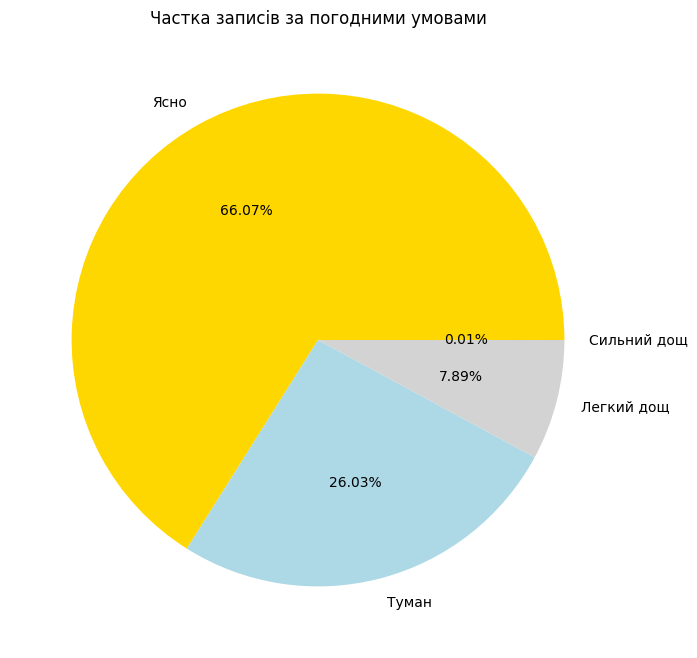

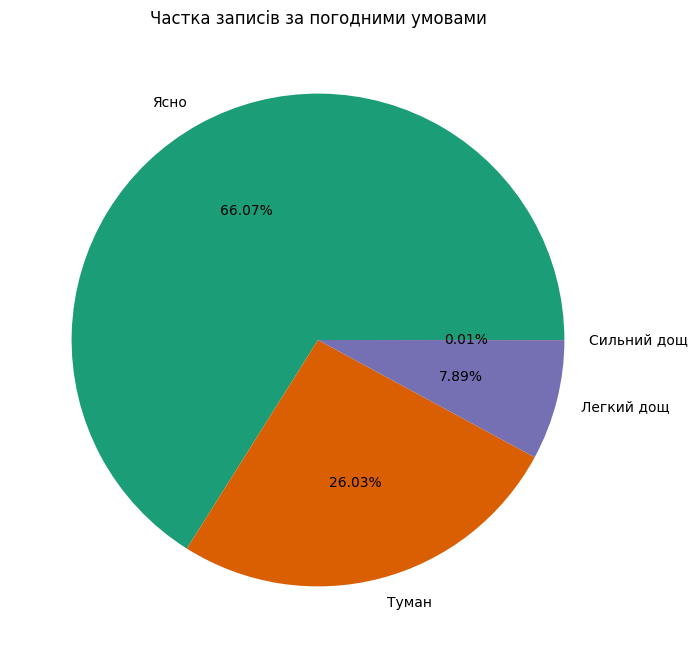

In [12]:
weather_ = df.weather.value_counts()
weather_.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors = plt.cm.Dark2.colors
);

In [ ]:
В датасеті переважає ясна погода - 66,07%.
Дні з сильними дощами також присутні, проте їх частка незначна - 0,01%
Погодні умови це важливий фактор для оренди велосипедів, тому що велопрогулянка здійснюється під відкритим небом.


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

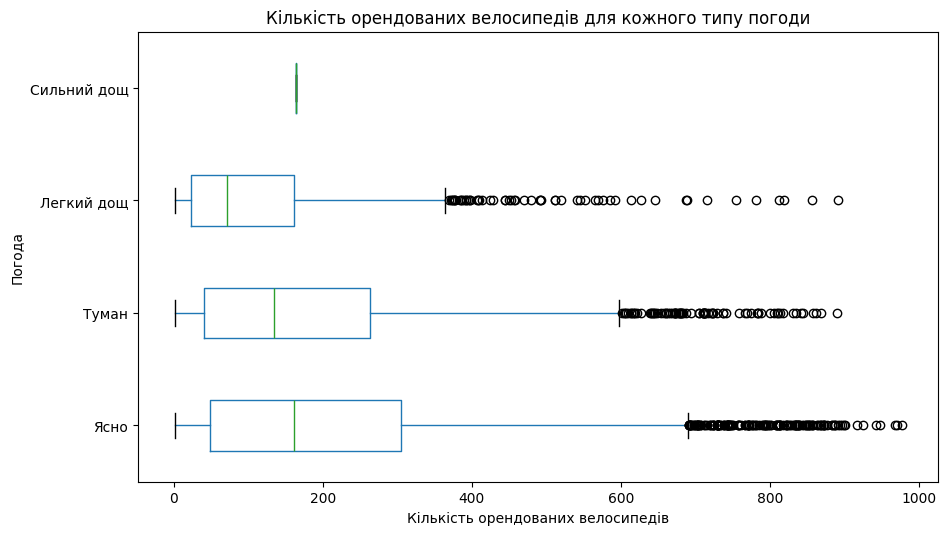

In [13]:
df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    vert = False,
    #tick_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    grid = False
)
plt.title('Кількість орендованих велосипедів для кожного типу погоди')
plt.suptitle('')  # Видаляємо автоматичний заголовок
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Погода')
plt.yticks([1, 2, 3, 4] , ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.show()

In [ ]:
Найбільший розкид бачимо при погоді "Ясно" та "Туман"
Викиди присутні при погоді "Ясно","Туман" та "Легкий дощ". Найбільша їх кількість для "Легкого дощу"
від позначки приблизно 380 до 950.
Медіанне значення оренди найвище в ясну погоду.   

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

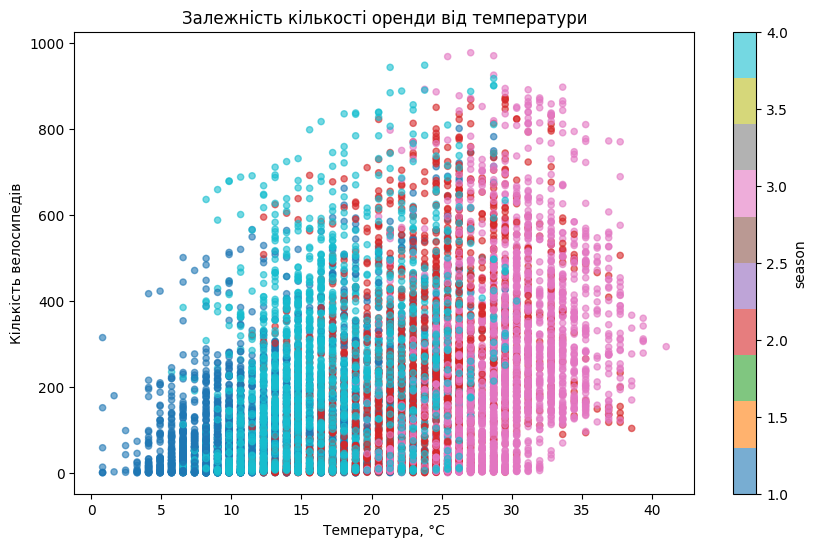

In [15]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='tab10',
    title='Залежність кількості оренди від температури',
    figsize=(10, 6),
    alpha=0.6
)
plt.xlabel('Температура, °C')
plt.ylabel('Кількість велосипедів')
plt.show()

In [ ]:
Між температурою та кількістю орендованих велосипедів є залежність. Найбільша кількість оренди 
при температурі 15-30 градусів.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

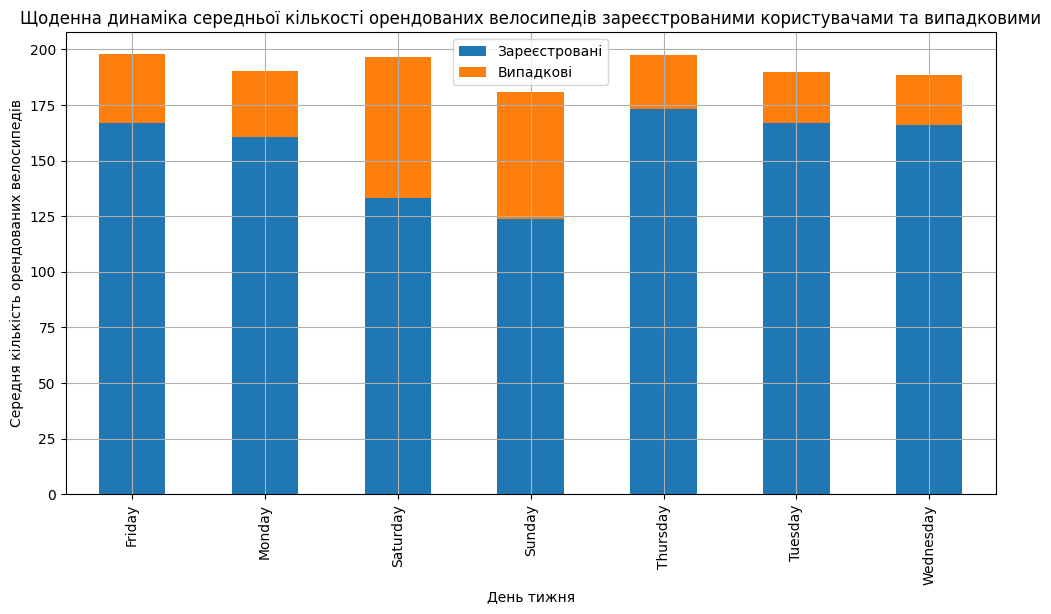

In [12]:
mean_count_of_day = df.groupby(['weekday'])[['registered','casual']].mean()

ax2= mean_count_of_day.plot.bar(
    figsize=(12, 6), 
    title='Щоденна динаміка середньої кількості орендованих велосипедів зареєстрованими користувачами та випадковими',
    xlabel='День тижня',
    ylabel='Середня кількість орендованих велосипедів',
    stacked=True,
    grid=True
)
plt.legend(labels=['Зареєстровані','Випадкові'])
plt.show()

In [ ]:
Найбільша кількість оренд велосипедів від зареєстрованих користувачів з понеділка по п'ятницю. Можна припустити,
що ці люди використовують велосипед, щоб доїхати на роботу та повернутись додому. 
В суботу та неділю зростає кількість оренд від випадкових користувачів, можливо це випадкове рішення проїхатись на велосипеді
в гарну погоду.